# E2E Event Classification with Sparse Neural Networks

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## Installing packages (h5py added for HDF5 files)

In [2]:
!pip install torch torchvision numpy matplotlib h5py -q

import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


## Creating folders

In [3]:
import os
for f in ['data/unlabelled','data/labelled','saved_models','results']:
    os.makedirs(f, exist_ok=True)
print('Folders created')
!ls

Folders created
data  results  sample_data  saved_models


## Downloading datasets


In [7]:
!wget -q --show-progress -O data/unlabelled/Dataset_Specific_Unlabelled.h5 "https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_Unlabelled.h5"
!wget -q --show-progress -O data/labelled/Dataset_Specific_labelled.h5 "https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_labelled.h5"

!ls -lh data/unlabelled/
!ls -lh data/labelled/

data/unlabelled/Dat 100%[===================>]  27.94G  29.8MB/s    in 13m 30s

data/labelled/Datas 100%[===================>]   4.66G  39.1MB/s    in 2m 42s

total 28G
-rw-r--r-- 1 root root 28G Mar  1  2025 Dataset_Specific_Unlabelled.h5
total 4.7G
-rw-r--r-- 1 root root 4.7G Mar  1  2025 Dataset_Specific_labelled.h5


In [ ]:
import h5py
import numpy as np

with h5py.File('data/unlabelled/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("unlabelled keys:", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: {f[k].shape}, {f[k].dtype}")

print()

with h5py.File('data/labelled/Dataset_Specific_labelled.h5', 'r') as f:
    print("labelled keys:", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: {f[k].shape}, {f[k].dtype}")

In [6]:
DATA_KEY  = 'jet'
LABEL_KEY = 'Y'

with h5py.File('data/unlabelled/Dataset_Specific_Unlabelled.h5', 'r') as f:
    sample = np.array(f[DATA_KEY][0]).astype(np.float32)
    print('unlabelled sample shape:', sample.shape)
    print('total unlabelled:', f[DATA_KEY].shape[0])

with h5py.File('data/labelled/Dataset_Specific_labelled.h5', 'r') as f:
    print('total labelled:', f[DATA_KEY].shape[0])
    labels = np.array(f[LABEL_KEY])
    unique, counts = np.unique(labels, return_counts=True)
    print('class counts:', dict(zip(unique.tolist(), counts.tolist())))

if sample.ndim == 2:
    sample = sample[np.newaxis]
elif sample.ndim == 3 and sample.shape[-1] < sample.shape[0]:
    sample = sample.transpose(2, 0, 1)

IN_CH, H, W = sample.shape
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'\nIN_CH={IN_CH}  H={H}  W={W}  device={DEVICE}')

unlabelled sample shape: (125, 125, 8)
total unlabelled: 60000
total labelled: 10000
class counts: {0.0: 5122, 1.0: 4878}

IN_CH=8  H=125  W=125  device=cuda


## Dataset classes (handles HDF5)

In [ ]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader, random_split

def preprocess(arr):
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    elif arr.ndim == 3 and arr.shape[-1] < arr.shape[0]:
        arr = arr.transpose(2,0,1)
    mu, sigma = arr.mean(), arr.std() + 1e-8
    return torch.tensor((arr - mu) / sigma)


class UnlabelledH5Dataset(Dataset):
    def __init__(self, path, data_key):
        self.path     = path
        self.data_key = data_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]
        print(f'[Unlabelled] {self.length} samples  file: {path}')

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr = np.array(f[self.data_key][i])
        return preprocess(arr)


class LabelledH5Dataset(Dataset):
    def __init__(self, path, data_key, label_key):
        self.path      = path
        self.data_key  = data_key
        self.label_key = label_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]
            labels      = np.array(f[label_key])
        unique, counts = np.unique(labels, return_counts=True)
        print(f'[Labelled]   {self.length} samples  '
              f'classes: {dict(zip(unique.tolist(), counts.tolist()))}')

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr   = np.array(f[self.data_key][i])
            label = float(f[self.label_key][i])
        return preprocess(arr), torch.tensor(label)


def make_loaders(dataset, val_fraction=0.15, batch_size=32, workers=2):
    n_val   = max(1, int(len(dataset) * val_fraction))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=workers,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=workers,
                              pin_memory=True)
    return train_loader, val_loader


# Build datasets
unlab_ds = UnlabelledH5Dataset(
    'data/unlabelled/Dataset_Specific_Unlabelled.h5', DATA_KEY)
lab_ds   = LabelledH5Dataset(
    'data/labelled/Dataset_Specific_labelled.h5', DATA_KEY, LABEL_KEY)

# sanity check
sample_x          = unlab_ds[0]
sample_x2, lbl    = lab_ds[0]
print(f'\nUnlabelled sample shape : {sample_x.shape}')
print(f'Labelled   sample shape : {sample_x2.shape}  label={lbl.item()}')
print('\nDatasets ready!')

[Unlabelled] 60000 samples  file: data/unlabelled/Dataset_Specific_Unlabelled.h5
[Labelled]   10000 samples  classes: {0.0: 5122, 1.0: 4878}

Unlabelled sample shape : torch.Size([8, 125, 125])
Labelled   sample shape : torch.Size([8, 125, 125])  label=1.0

✅ Datasets ready!


/tmp/ipykernel_10865/979111103.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = float(f[self.label_key][i])


In [24]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader, random_split

def preprocess(arr):
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    elif arr.ndim == 3 and arr.shape[-1] < arr.shape[0]:
        arr = arr.transpose(2, 0, 1)
    mu, sigma = arr.mean(), arr.std() + 1e-8
    return torch.tensor((arr - mu) / sigma)


class UnlabelledH5Dataset(Dataset):
    def __init__(self, path, data_key):
        self.path     = path
        self.data_key = data_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr = np.array(f[self.data_key][i])
        return preprocess(arr)


class LabelledH5Dataset(Dataset):
    def __init__(self, path, data_key, label_key):
        self.path      = path
        self.data_key  = data_key
        self.label_key = label_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]
            labels      = np.array(f[label_key])
        unique, counts = np.unique(labels, return_counts=True)
        print(dict(zip(unique.tolist(), counts.tolist())))

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr   = np.array(f[self.data_key][i])
            label = float(np.array(f[self.label_key][i]).item())
        return preprocess(arr), torch.tensor(label)


def make_loaders(dataset, val_fraction=0.15, batch_size=32, workers=2):
    n_val   = max(1, int(len(dataset) * val_fraction))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=workers,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=workers,
                              pin_memory=True)
    return train_loader, val_loader


unlab_ds = UnlabelledH5Dataset('data/unlabelled/Dataset_Specific_Unlabelled.h5', DATA_KEY)
lab_ds   = LabelledH5Dataset('data/labelled/Dataset_Specific_labelled.h5', DATA_KEY, LABEL_KEY)

sample_x       = unlab_ds[0]
sample_x2, lbl = lab_ds[0]
print(sample_x.shape)
print(sample_x2.shape, lbl.item())

{0.0: 5122, 1.0: 4878}
torch.Size([8, 125, 125])
torch.Size([8, 125, 125]) 1.0


In [8]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader, random_split

def preprocess(arr):
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    elif arr.ndim == 3 and arr.shape[-1] < arr.shape[0]:
        arr = arr.transpose(2, 0, 1)
    mu, sigma = arr.mean(), arr.std() + 1e-8
    return torch.tensor((arr - mu) / sigma)


class UnlabelledH5Dataset(Dataset):
    def __init__(self, path, data_key):
        self.path     = path
        self.data_key = data_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr = np.array(f[self.data_key][i])
        return preprocess(arr)


class LabelledH5Dataset(Dataset):
    def __init__(self, path, data_key, label_key):
        self.path      = path
        self.data_key  = data_key
        self.label_key = label_key
        with h5py.File(path, 'r') as f:
            self.length = f[data_key].shape[0]
            labels      = np.array(f[label_key])
        unique, counts = np.unique(labels, return_counts=True)
        print(dict(zip(unique.tolist(), counts.tolist())))

    def __len__(self):  return self.length

    def __getitem__(self, i):
        with h5py.File(self.path, 'r') as f:
            arr   = np.array(f[self.data_key][i])
            label = float(np.array(f[self.label_key][i]).item())
        return preprocess(arr), torch.tensor(label)


def make_loaders(dataset, val_fraction=0.15, batch_size=32, workers=2):
    n_val   = max(1, int(len(dataset) * val_fraction))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=workers,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=workers,
                              pin_memory=True)
    return train_loader, val_loader


unlab_ds = UnlabelledH5Dataset('data/unlabelled/Dataset_Specific_Unlabelled.h5', DATA_KEY)
lab_ds   = LabelledH5Dataset('data/labelled/Dataset_Specific_labelled.h5', DATA_KEY, LABEL_KEY)

sample_x       = unlab_ds[0]
sample_x2, lbl = lab_ds[0]
print(sample_x.shape)
print(sample_x2.shape, lbl.item())

{0.0: 5122, 1.0: 4878}
torch.Size([8, 125, 125])
torch.Size([8, 125, 125]) 1.0


In [9]:
import torch.nn as nn
import torch.nn.functional as F


class SparseConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel,
                              stride=stride, padding=kernel//2, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        mask     = (x.abs().max(dim=1, keepdim=True).values > 0).float()
        out      = F.relu(self.bn(self.conv(x * mask)), inplace=True)
        if self.conv.stride[0] > 1:
            out_mask = F.max_pool2d(mask, self.conv.stride[0],
                                    self.conv.stride[0])
        else:
            out_mask = mask
        out_mask = (F.interpolate(out_mask, size=out.shape[-2:],
                                  mode='nearest') > 0).float()
        return out * out_mask


class SparseEncoder(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.s1   = nn.Sequential(SparseConvBlock(in_ch,16), SparseConvBlock(16,16))
        self.p1   = nn.MaxPool2d(2,2)
        self.s2   = nn.Sequential(SparseConvBlock(16,32),  SparseConvBlock(32,32))
        self.p2   = nn.MaxPool2d(2,2)
        self.s3   = nn.Sequential(SparseConvBlock(32,64),  SparseConvBlock(64,64))
        self.p3   = nn.MaxPool2d(2,2)
        self.s4   = nn.Sequential(SparseConvBlock(64,128), SparseConvBlock(128,128))
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.p1(self.s1(x))
        x = self.p2(self.s2(x))
        x = self.p3(self.s3(x))
        x = self.s4(x)
        return self.pool(x).view(x.size(0), -1)


class SparseDecoder(nn.Module):
    def __init__(self, out_ch=2):
        super().__init__()
        self.proj = nn.Linear(128, 128*4*4)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64,4,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 64, 32,4,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 32, 16,4,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(16),  nn.ReLU(inplace=True),
            nn.Conv2d(16, out_ch, 3, padding=1),
        )

    def forward(self, z):
        x = self.proj(z).view(z.size(0), 128, 4, 4)
        return self.net(x)


class BaselineAE(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.encoder = SparseEncoder(in_ch)
        self.decoder = SparseDecoder(in_ch)

    def forward(self, x):
        z = self.encoder(x)
        r = self.decoder(z)
        if r.shape[-2:] != x.shape[-2:]:
            r = F.interpolate(r, size=x.shape[-2:],
                              mode='bilinear', align_corners=False)
        return r, z


class Classifier(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.encoder = SparseEncoder(in_ch)
        self.head    = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.3),    nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.head(self.encoder(x))

    def load_encoder(self, ae):
        self.encoder.load_state_dict(ae.encoder.state_dict())
        print('Encoder weights copied from pretrained autoencoder')


class SparseAE(nn.Module):
    def __init__(self, in_ch=2, sparsity_weight=1e-3):
        super().__init__()
        self.sw       = sparsity_weight
        self.encoder  = SparseEncoder(in_ch)
        self.sparse   = nn.Linear(128, 256)
        self.compress = nn.Linear(256, 128)
        self.decoder  = SparseDecoder(in_ch)

    def forward(self, x):
        z  = self.encoder(x)
        zs = F.relu(self.sparse(z))
        sl = self.sw * zs.abs().mean()
        r  = self.decoder(self.compress(zs))
        if r.shape[-2:] != x.shape[-2:]:
            r = F.interpolate(r, size=x.shape[-2:],
                              mode='bilinear', align_corners=False)
        return r, zs, sl


dummy    = torch.zeros(2, IN_CH, H, W)
ae_test  = BaselineAE(in_ch=IN_CH)
r, z     = ae_test(dummy)
clf_test = Classifier(in_ch=IN_CH)
logit    = clf_test(dummy)

print(f'BaselineAE  : {sum(p.numel() for p in ae_test.parameters()):,} params')
print(f'Classifier  : {sum(p.numel() for p in clf_test.parameters()):,} params')
print(f'encoder output: {z.shape}')
print(f'classifier output: {logit.shape}')

BaselineAE  : 732,328 params
Classifier  : 303,041 params
encoder output: torch.Size([2, 128])
classifier output: torch.Size([2, 1])


## Training  Autoencoder on Unlabelled Data


In [10]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

AE_EPOCHS = 50
AE_BATCH  = 32
AE_LR     = 1e-3

unlab_train, unlab_val = make_loaders(unlab_ds, batch_size=AE_BATCH)
ae        = BaselineAE(in_ch=IN_CH).to(DEVICE)
optimizer = Adam(ae.parameters(), lr=AE_LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=AE_EPOCHS)

best_val      = float('inf')
ae_train_hist = []
ae_val_hist   = []

for epoch in range(1, AE_EPOCHS + 1):
    ae.train()
    tl = 0.0
    for x in unlab_train:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        recon, _ = ae(x)
        loss = F.mse_loss(recon, x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae.parameters(), 1.0)
        optimizer.step()
        tl += loss.item() * x.size(0)
    tl /= len(unlab_train.dataset)

    ae.eval()
    vl = 0.0
    with torch.no_grad():
        for x in unlab_val:
            x = x.to(DEVICE)
            recon, _ = ae(x)
            vl += F.mse_loss(recon, x).item() * x.size(0)
    vl /= len(unlab_val.dataset)
    scheduler.step()
    ae_train_hist.append(tl)
    ae_val_hist.append(vl)

    saved = ''
    if vl < best_val:
        best_val = vl
        torch.save({'model_state': ae.state_dict(),
                    'in_ch': IN_CH, 'epoch': epoch},
                   'saved_models/autoencoder.pth')
        saved = '  saved'

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{AE_EPOCHS}  train={tl:.5f}  val={vl:.5f}{saved}')

print(f'\nbest val loss: {best_val:.5f}')

Epoch   1/50  train=0.82131  val=0.81260  saved
Epoch   5/50  train=0.78059  val=0.78243  saved
Epoch  10/50  train=0.77206  val=0.77340  saved
Epoch  15/50  train=0.76782  val=0.76909
Epoch  20/50  train=0.76481  val=0.76547  saved
Epoch  25/50  train=0.76234  val=0.76340
Epoch  30/50  train=0.76019  val=0.75992  saved
Epoch  35/50  train=0.75823  val=0.75822  saved
Epoch  40/50  train=0.75657  val=0.75706  saved
Epoch  45/50  train=0.75544  val=0.75597  saved
Epoch  50/50  train=0.75497  val=0.75570  saved

best val loss: 0.75570


## Ploting autoencoder loss curve

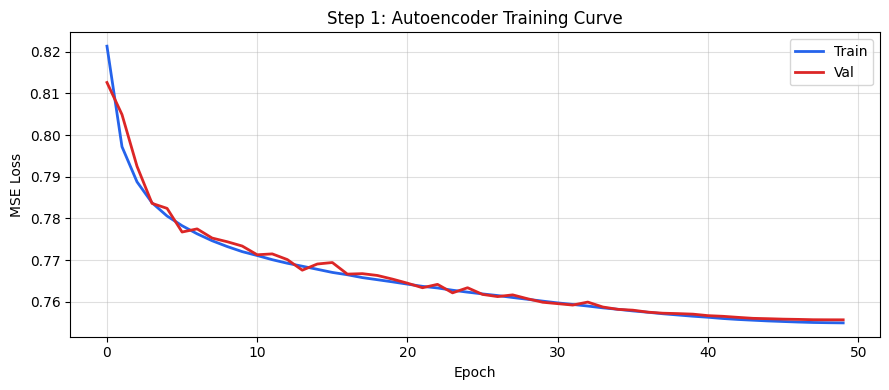

✅ Saved: results/ae_loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(ae_train_hist, label='Train', color='#2563EB', linewidth=2)
plt.plot(ae_val_hist,   label='Val',   color='#DC2626', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Step 1: Autoencoder Training Curve')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('results/ae_loss_curve.png', dpi=150)
plt.show()
print('✅ Saved: results/ae_loss_curve.png')

##Fine-tune Classifier on Labeled Data


In [11]:
CLF_EPOCHS = 30
CLF_BATCH  = 32
CLF_LR     = 5e-4

lab_train, lab_val = make_loaders(lab_ds, batch_size=CLF_BATCH)

ckpt = torch.load('saved_models/autoencoder.pth', map_location=DEVICE)
ae_loaded = BaselineAE(in_ch=IN_CH)
ae_loaded.load_state_dict(ckpt['model_state'])

clf = Classifier(in_ch=IN_CH).to(DEVICE)
clf.load_encoder(ae_loaded)

opt = Adam(clf.parameters(), lr=CLF_LR, weight_decay=1e-5)
sch = CosineAnnealingLR(opt, T_max=CLF_EPOCHS)

best_err      = float('inf')
clf_loss_hist = []
clf_err_hist  = []

for epoch in range(1, CLF_EPOCHS + 1):
    clf.train()
    tl = 0.0
    for x, y in lab_train:
        x, y = x.to(DEVICE), y.to(DEVICE).unsqueeze(1)
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(clf(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf.parameters(), 1.0)
        opt.step()
        tl += loss.item() * x.size(0)
    tl /= len(lab_train.dataset)

    clf.eval()
    vl = correct = total = 0
    with torch.no_grad():
        for x, y in lab_val:
            x, y    = x.to(DEVICE), y.to(DEVICE).unsqueeze(1)
            logits   = clf(x)
            vl      += F.binary_cross_entropy_with_logits(logits, y).item() * x.size(0)
            correct  += ((torch.sigmoid(logits) >= 0.5).float() == y).sum().item()
            total    += x.size(0)
    vl  /= total
    err  = 1.0 - correct / total
    sch.step()

    clf_loss_hist.append(tl)
    clf_err_hist.append(err)

    saved = ''
    if err < best_err:
        best_err = err
        torch.save({'model_state': clf.state_dict(),
                    'in_ch': IN_CH, 'val_error': err},
                   'saved_models/classifier.pth')
        saved = '  saved'

    print(f'Epoch {epoch:3d}/{CLF_EPOCHS}  loss={tl:.4f}  error={err:.4f}  acc={1-err:.4f}{saved}')

print(f'\nbest error: {best_err:.4f}  acc: {1-best_err:.4f}')

Encoder weights copied from pretrained autoencoder
Epoch   1/30  loss=0.4272  error=0.1200  acc=0.8800  saved
Epoch   2/30  loss=0.3026  error=0.1033  acc=0.8967  saved
Epoch   3/30  loss=0.2863  error=0.1387  acc=0.8613
Epoch   4/30  loss=0.2719  error=0.1007  acc=0.8993  saved
Epoch   5/30  loss=0.2577  error=0.1247  acc=0.8753
Epoch   6/30  loss=0.2492  error=0.1373  acc=0.8627
Epoch   7/30  loss=0.2448  error=0.0980  acc=0.9020  saved
Epoch   8/30  loss=0.2321  error=0.1147  acc=0.8853
Epoch   9/30  loss=0.2250  error=0.1133  acc=0.8867
Epoch  10/30  loss=0.2082  error=0.0947  acc=0.9053  saved
Epoch  11/30  loss=0.1983  error=0.1380  acc=0.8620
Epoch  12/30  loss=0.1804  error=0.1107  acc=0.8893
Epoch  13/30  loss=0.1584  error=0.1087  acc=0.8913
Epoch  14/30  loss=0.1506  error=0.1140  acc=0.8860
Epoch  15/30  loss=0.1244  error=0.1107  acc=0.8893
Epoch  16/30  loss=0.1018  error=0.1153  acc=0.8847
Epoch  17/30  loss=0.0897  error=0.1327  acc=0.8673
Epoch  18/30  loss=0.0701  err



##Plot classifier training curves

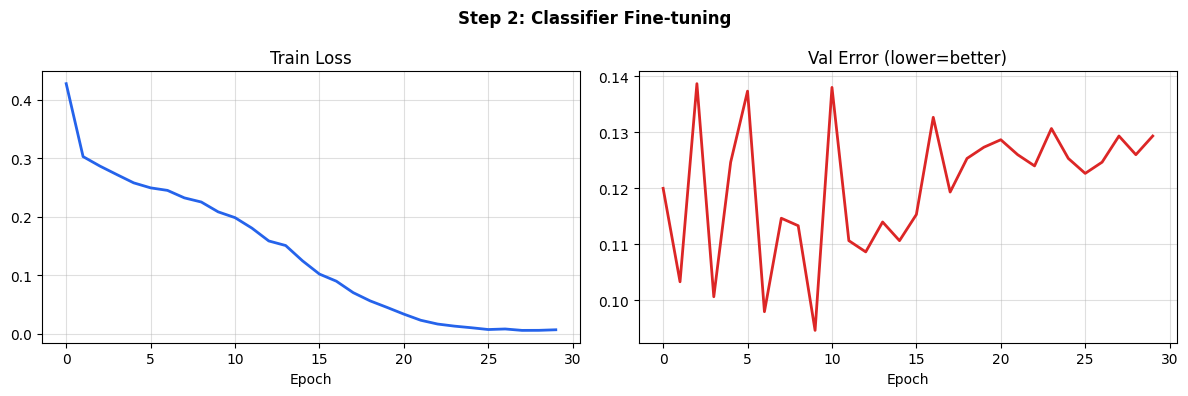

✅ Saved: results/clf_training_curve.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(clf_loss_hist, color='#2563EB', linewidth=2)
ax1.set_title('Train Loss');  ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.4)
ax2.plot(clf_err_hist,  color='#DC2626', linewidth=2)
ax2.set_title('Val Error (lower=better)'); ax2.set_xlabel('Epoch'); ax2.grid(True, alpha=0.4)
plt.suptitle('Step 2: Classifier Fine-tuning', fontweight='bold')
plt.tight_layout()
plt.savefig('results/clf_training_curve.png', dpi=150)
plt.show()
print('✅ Saved: results/clf_training_curve.png')

## Pruning Experiment


In [12]:
import torch.nn.utils.prune as torch_prune
import json
import matplotlib.ticker as ticker


def count_flops(model, input_size):
    total = [0.0]
    hooks = []
    def conv_hook(m, inp, out):
        b, co, h, w = out.shape
        ci = inp[0].shape[1]
        kH, kW = m.kernel_size
        density = (m.weight != 0).float().mean().item()
        total[0] += 2 * (ci/m.groups) * kH * kW * co * h * w * density
    def lin_hook(m, inp, out):
        density = (m.weight != 0).float().mean().item()
        total[0] += 2 * m.in_features * m.out_features * density
    for m in model.modules():
        if isinstance(m, nn.Conv2d):   hooks.append(m.register_forward_hook(conv_hook))
        if isinstance(m, nn.Linear):   hooks.append(m.register_forward_hook(lin_hook))
    with torch.no_grad():
        try: model(torch.zeros(1, *input_size, device=DEVICE))
        except: pass
    for h in hooks: h.remove()
    return total[0]

def get_sparsity(model):
    total = zeros = 0
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            total += m.weight.numel()
            zeros += (m.weight == 0).sum().item()
    return zeros / total if total > 0 else 0.0

def evaluate(model, loader):
    model.eval()
    tl = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE).unsqueeze(1)
            logits  = model(x)
            tl     += F.binary_cross_entropy_with_logits(logits, y).item() * x.size(0)
            correct += ((torch.sigmoid(logits) >= 0.5).float() == y).sum().item()
            total   += x.size(0)
    return tl/total, 1.0 - correct/total

def apply_pruning(model, amount):
    params = [(m, 'weight') for m in model.modules()
              if isinstance(m, (nn.Conv2d, nn.Linear))]
    torch_prune.global_unstructured(
        params, pruning_method=torch_prune.L1Unstructured, amount=amount)
    for m, _ in params:
        try: torch_prune.remove(m, 'weight')
        except: pass
    return model

def pruning_sweep(ckpt_path, label):
    ratios     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    results    = []
    input_size = (IN_CH, H, W)
    for ratio in ratios:
        m = Classifier(in_ch=IN_CH).to(DEVICE)
        m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state'])
        if ratio > 0:
            apply_pruning(m, ratio)
        flops    = count_flops(m, input_size)
        _, err   = evaluate(m, lab_val)
        sparsity = get_sparsity(m)
        print(f'{ratio:.0%}  sparsity={sparsity:.3f}  flops={flops/1e6:.2f}M  error={err:.4f}  acc={1-err:.4f}')
        results.append({'ratio': ratio, 'flops': flops, 'error': err, 'sparsity': sparsity})
    return results

baseline_results = pruning_sweep('saved_models/classifier.pth', 'Baseline')

with open('results/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

0%   sparsity=0.000  flops=420.11M  error=0.1740  acc=0.8260
10%  sparsity=0.100  flops=349.27M  error=0.1740  acc=0.8260
20%  sparsity=0.200  flops=301.05M  error=0.1740  acc=0.8260
30%  sparsity=0.300  flops=273.20M  error=0.1740  acc=0.8260
40%  sparsity=0.400  flops=252.40M  error=0.1713  acc=0.8287
50%  sparsity=0.500  flops=226.95M  error=0.1573  acc=0.8427
60%  sparsity=0.600  flops=195.32M  error=0.1400  acc=0.8600
70%  sparsity=0.700  flops=154.63M  error=0.1273  acc=0.8727
80%  sparsity=0.800  flops=108.75M  error=0.4013  acc=0.5987
90%  sparsity=0.900  flops=56.74M   error=0.5173  acc=0.4827


## Plot - FLOPs vs Error (Baseline)

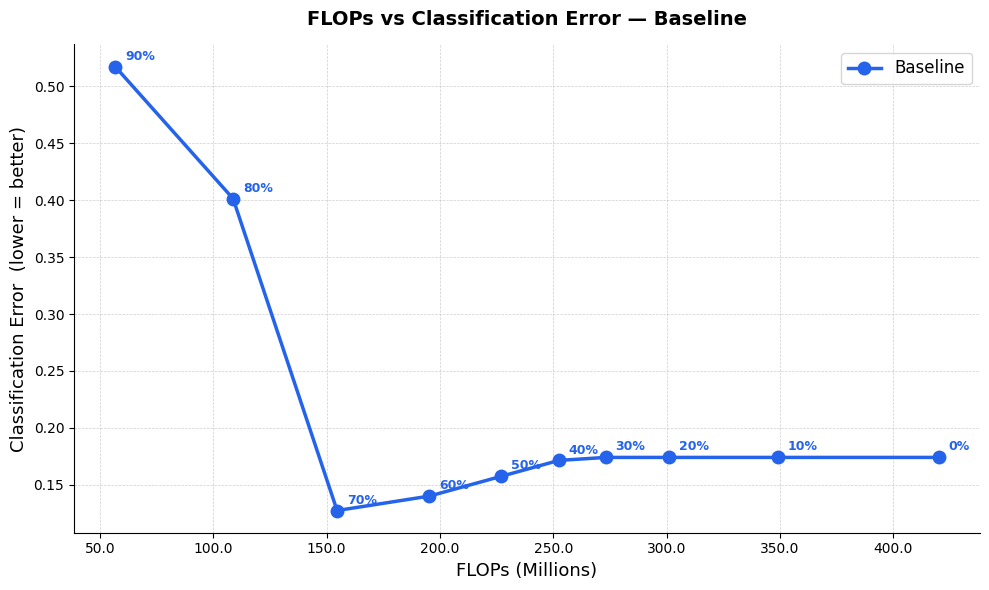

✅ Plot saved: results/flops_vs_error_baseline.png


In [ ]:
def make_plot(series_dict, out_path, title):
    colours = {'Baseline':'#2563EB', 'Sparse AE':'#DC2626'}
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, results in series_dict.items():
        c      = colours.get(label, '#16A34A')
        flops  = [r['flops'] for r in results]
        errors = [r['error'] for r in results]
        ratios = [r['ratio'] for r in results]
        ax.plot(flops, errors, 'o-', color=c, linewidth=2.5,
                markersize=9, label=label)
        for f, e, r in zip(flops, errors, ratios):
            ax.annotate(f'{r:.0%}', (f, e),
                        textcoords='offset points', xytext=(7, 5),
                        fontsize=9, color=c, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('FLOPs (Millions)', fontsize=13)
    ax.set_ylabel('Classification Error  (lower = better)', fontsize=13)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Plot saved: {out_path}')

make_plot(
    {'Baseline': baseline_results},
    'results/flops_vs_error_baseline.png',
    'FLOPs vs Classification Error — Baseline'
)

BONUS: Train Sparse Autoencoder

In [13]:
BONUS_AE_EPOCHS = 30

unlab_tr2, unlab_vl2 = make_loaders(unlab_ds, batch_size=32)
sae = SparseAE(in_ch=IN_CH).to(DEVICE)
opt = Adam(sae.parameters(), lr=1e-3, weight_decay=1e-5)
sch = CosineAnnealingLR(opt, T_max=BONUS_AE_EPOCHS)

best_sae = float('inf')

for epoch in range(1, BONUS_AE_EPOCHS + 1):
    sae.train()
    tl = 0.0
    for x in unlab_tr2:
        x = x.to(DEVICE)
        opt.zero_grad()
        recon, _, sl = sae(x)
        loss = F.mse_loss(recon, x) + sl
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sae.parameters(), 1.0)
        opt.step()
        tl += loss.item() * x.size(0)
    tl /= len(unlab_tr2.dataset)

    sae.eval()
    vl = 0.0
    with torch.no_grad():
        for x in unlab_vl2:
            x = x.to(DEVICE)
            recon, _, sl = sae(x)
            vl += (F.mse_loss(recon, x) + sl).item() * x.size(0)
    vl /= len(unlab_vl2.dataset)
    sch.step()

    saved = ''
    if vl < best_sae:
        best_sae = vl
        torch.save({'model_state': sae.state_dict(), 'in_ch': IN_CH},
                   'saved_models/sparse_ae.pth')
        saved = '  saved'

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{BONUS_AE_EPOCHS}  train={tl:.5f}  val={vl:.5f}{saved}')

print(f'\nbest val: {best_sae:.5f}')

Epoch   1/30  train=0.82955  val=0.82166  saved
Epoch   5/30  train=0.79958  val=0.80643  saved
Epoch  10/30  train=0.78816  val=0.79739
Epoch  15/30  train=0.78210  val=0.78661
Epoch  20/30  train=0.77792  val=0.78096  saved
Epoch  25/30  train=0.77490  val=0.77885  saved
Epoch  30/30  train=0.77354  val=0.77778  saved

best val: 0.77778


## Fine-tune classifier from Sparse AE encoder

In [14]:
sae_ckpt   = torch.load('saved_models/sparse_ae.pth', map_location=DEVICE)
sae_loaded = SparseAE(in_ch=IN_CH)
sae_loaded.load_state_dict(sae_ckpt['model_state'])

sp_clf = Classifier(in_ch=IN_CH).to(DEVICE)
sp_clf.encoder.load_state_dict(sae_loaded.encoder.state_dict())

opt2 = Adam(sp_clf.parameters(), lr=5e-4, weight_decay=1e-5)
sch2 = CosineAnnealingLR(opt2, T_max=20)
best_sp = float('inf')

for epoch in range(1, 21):
    sp_clf.train()
    for x, y in lab_train:
        x, y = x.to(DEVICE), y.to(DEVICE).unsqueeze(1)
        opt2.zero_grad()
        F.binary_cross_entropy_with_logits(sp_clf(x), y).backward()
        opt2.step()
    sch2.step()
    _, err = evaluate(sp_clf, lab_val)
    saved = ''
    if err < best_sp:
        best_sp = err
        torch.save({'model_state': sp_clf.state_dict(),
                    'in_ch': IN_CH, 'val_error': err},
                   'saved_models/sparse_classifier.pth')
        saved = '  saved'
    print(f'Epoch {epoch:3d}/20  error={err:.4f}  acc={1-err:.4f}{saved}')

print(f'\nbest error: {best_sp:.4f}')

Encoder loaded from Sparse AE
Epoch   1/20  error=0.1440  acc=0.8560  saved
Epoch   2/20  error=0.1207  acc=0.8793  saved
Epoch   3/20  error=0.1013  acc=0.8987  saved
Epoch   4/20  error=0.1633  acc=0.8367
Epoch   5/20  error=0.1513  acc=0.8487
Epoch   6/20  error=0.1080  acc=0.8920
Epoch   7/20  error=0.1247  acc=0.8753
Epoch   8/20  error=0.1933  acc=0.8067
Epoch   9/20  error=0.0980  acc=0.9020  saved
Epoch  10/20  error=0.0980  acc=0.9020
Epoch  11/20  error=0.1107  acc=0.8893
Epoch  12/20  error=0.1087  acc=0.8913
Epoch  13/20  error=0.0947  acc=0.9053  saved
Epoch  14/20  error=0.1040  acc=0.8960
Epoch  15/20  error=0.1047  acc=0.8953
Epoch  16/20  error=0.1000  acc=0.9000
Epoch  17/20  error=0.1020  acc=0.8980
Epoch  18/20  error=0.1027  acc=0.8973
Epoch  19/20  error=0.0987  acc=0.9013
Epoch  20/20  error=0.1033  acc=0.8967

best error: 0.0947


## Pruning sweep + Comparison Plot ← BONUS PLOT

0%   sparsity=0.000  flops=420.11M  error=0.1040  acc=0.8960
10%  sparsity=0.100  flops=381.83M  error=0.1040  acc=0.8960
20%  sparsity=0.200  flops=326.29M  error=0.1040  acc=0.8960
30%  sparsity=0.300  flops=295.44M  error=0.1040  acc=0.8960
40%  sparsity=0.400  flops=267.59M  error=0.1040  acc=0.8960
50%  sparsity=0.500  flops=247.87M  error=0.1040  acc=0.8960
60%  sparsity=0.600  flops=215.49M  error=0.1040  acc=0.8960
70%  sparsity=0.700  flops=176.06M  error=0.1100  acc=0.8900
80%  sparsity=0.800  flops=129.23M  error=0.1660  acc=0.8340
90%  sparsity=0.900  flops=72.09M   error=0.5187  acc=0.4813


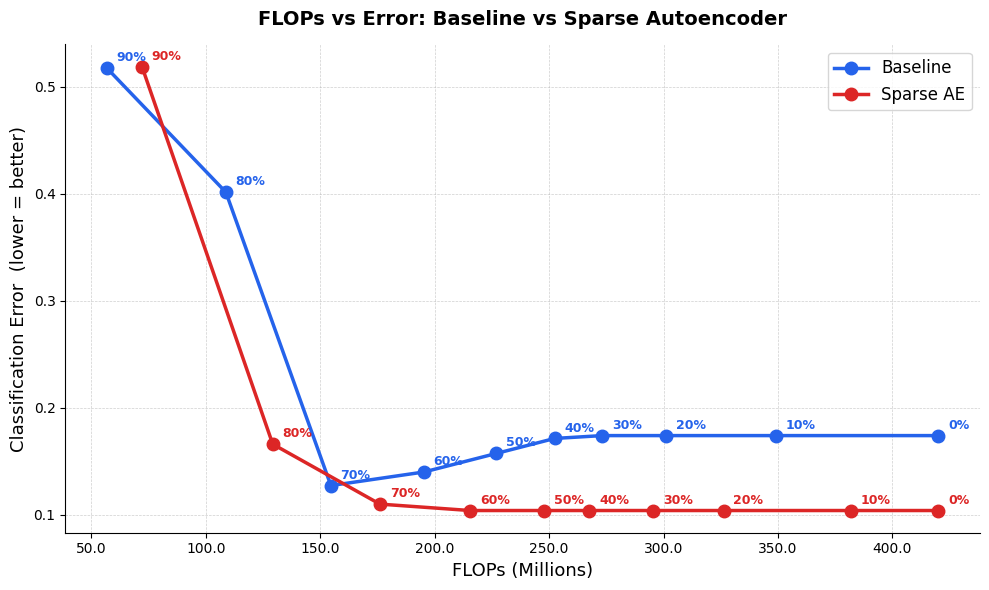

In [23]:
sparse_results = pruning_sweep('saved_models/sparse_classifier.pth', 'Sparse AE')

with open('results/sparse_results.json', 'w') as f:
    json.dump(sparse_results, f, indent=2)

make_plot(
    {'Baseline': baseline_results, 'Sparse AE': sparse_results},
    'results/flops_vs_error_comparison.png',
    'FLOPs vs Error: Baseline vs Sparse Autoencoder'
)